# "The effect of model resolution on air-sea CO$_{2}$ equilibration timescales "
## Code for Calculating the Parameterized Gas Transfer Velocity and Figure 5 (a), Figure S6 (c)
Corresponding to Yinghuan Xie (yinghuan.xie@utas.edu.au)

In [3]:
# Importing the relevant modules.
import numpy as np
import xarray as xr
import math
import time
import datetime as dt
from datetime import timedelta
from datetime import datetime
import calendar
import os
import re
from glob import glob
#
import netCDF4 as nc
import pandas as pd
import gsw
#
import cartopy.crs as ccrs
from scipy.io import loadmat
#
import matplotlib.pyplot as plt
import matplotlib.colors as col
#
import cosima_cookbook as cc
session =cc.database.create_session()
expt = '01deg_jra55v13_ryf9091'
#
from os import sys
sys.path.append('/home/581/yx9454/PhD_Ch1')
from My_Py_Func import Ch1_defs as c1d

import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

import cartopy.feature as cfeature
from PIL import Image, ImageSequence
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import cftime

# Declare and load global variables

In [2]:
main_directory = '/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result'
plot_dir = '/home/581/yx9454/GBC_Revision'

sites_ordered_labels=['Iceland','Ross Sea','Weddell Sea','Eastern Antarctica','Kuroshio Current','Gulf Stream','Western Australia','Tasmania','West of Gibraltar','Hawaii','Amazon','South China Sea']
exp_hemi =  {'02':'S','03':'N','04':  'S', '05': 'N','06':'S','07':'S','08':'N','09':'S','10':'S','11':'N','12':'S','13':'S', '16':'S','17':'N','18':'N','21':'N' }
exp_name =  {'02':'Eastern Australia','03':'Hawaii','04':  'Amazon', '05': 'Iceland','06':'Ross Sea','07':'Western Australia','08':'South China Sea','09':'Chile','10':'Brazil','11':'Eastern India','12':'Weddell Sea','13':'Eastern Antarctica', '16':'Tasmania','17':'Kuroshio Current','18':'West of Gibraltar','21':'Gulf Stream'}
exp_name_1 =  {2:'Eastern Australia',3:'Hawaii',4:  'Amazon', 5: 'Iceland',6:'Ross Sea',7:'Western Australia',8:'South China Sea',9:'Chile',10:'Brazil',11:'Eastern India',12:'Weddell Sea',13:'Eastern Antarctica', 16:'Tasmania',17:'Kuroshio Current',18:'West of Gibraltar',21:'Gulf Stream'}

sites_ordered_labels=['Iceland','Ross Sea','Weddell Sea','Eastern Antarctica','Kuroshio Current','Gulf Stream','Western Australia','Tasmania','West of Gibraltar','Hawaii','Amazon','South China Sea']

site_color = {'Iceland':'b','Ross Sea':'royalblue','Weddell Sea':'deepskyblue','Eastern Antarctica':'lightskyblue',
              'Kuroshio Current':'g','Gulf Stream':'limegreen',
              'Western Australia':'gold','Tasmania':'orange','West of Gibraltar':'goldenrod',
              'Hawaii':'orangered','Amazon':'crimson','South China Sea':'red'}

# Load very fine 1/10 degree DIC deficit values, which is slightly different from 0.25Tmol. 
# This issue does not exist in 0.25 and 1-degree experiment.
file_path = '/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/01deg_REAL_Deficit_Calculation/01deg_REAL_Deficit_Calculation.csv'  
df = pd.read_csv(file_path)
# Convert the Calculation time column to datetime format
df['Calculation time'] = pd.to_datetime(df['Calculation time'])
# Group by Site No and select the row with the latest Calculation time
all_tar_data_records = df.loc[df.groupby('Site No')['Calculation time'].idxmax()]
# Record the result in the dictionary
Real_DIC_dict = dict(zip(all_tar_data_records['Site No'], all_tar_data_records['Real DIC deficit'].astype(float)))


# Calculate the Gas Transfer Velocity (k) and Parameterized Gas Transfer Velocity (k/beta)
Only need to run for the first time.

In [6]:
# Manually define the resolution. 
model_res = 0.25 # 0.1/0.25/1

# Load wind
wind_ds = xr.open_dataset('/g/data/jk72/yx9454/GBC_Revision/u10m_approx_2004_1_to_2009_12.nc')
# Load surface temperature
temp_ds = xr.open_dataset('/g/data/jk72/yx9454/GBC_Revision/Monthly_Surf_pot_temp_K_180x360_'+str(model_res)+'_2004_1_to_2009_12.nc')
# Load carbonate buffer factor
beta2_ds = xr.open_dataset('/g/data/jk72/yx9454/GBC_Revision/'+str(model_res)+'deg_dpco2_ddic_and_dDIC_dCO2.nc').dDIC_dCO2
beta2_selected = beta2_ds.sel(time=slice('2004-01', '2008-12'))

ind = 60
if model_res==0.1:
    ind=48
beta2_selected = beta2_selected[:ind]
temp = temp_ds.__xarray_dataarray_variable__.data[:ind] -273.15
wind = wind_ds.__xarray_dataarray_variable__.data[:ind]
sc = 2073.1 - 125.62 * temp + 3.6276 * temp**2 - 0.043219 * temp**3

# Gas Transfer velicity (k)
k_dic = ( 0.31*wind**2*(sc / 660)**-0.5)*(1/beta2_selected)

# Parameterized Gas Transfer velicity (k/beta)
GT = ( 0.31*wind**2*(sc / 660)**-0.5)*(beta2_selected/beta2_selected)

# Save
k_dic.to_netcdf('/g/data/jk72/yx9454/GBC_Revision/Monthly_k_ddic_180x360_'+str(model_res)+'_2004_1_to_2008_12.nc')
GT.to_netcdf('/g/data/jk72/yx9454/GBC_Revision/Monthly_GT_180x360_'+str(model_res)+'_2004_1_to_2008_12.nc')

# Plotting Figure 5 (a) and Figure S6 (c)

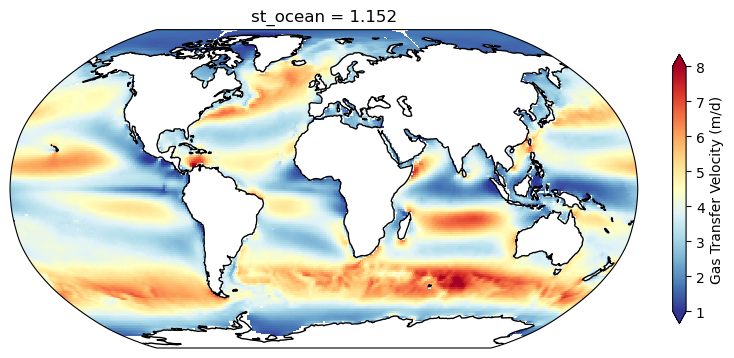

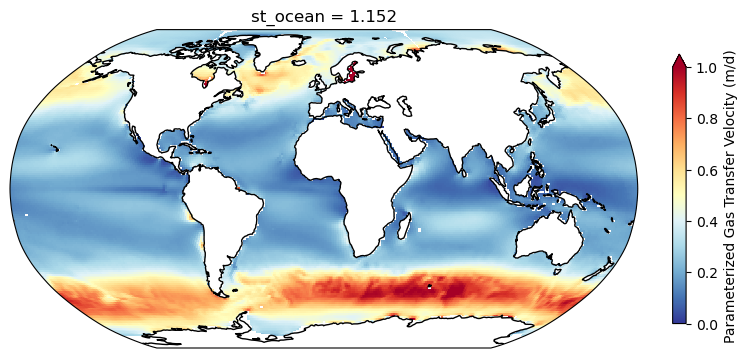

In [5]:
GT_Plotting = xr.open_dataset('/g/data/jk72/yx9454/GBC_Revision/Monthly_GT_180x360_1_2004_1_to_2008_12.nc')

fig = plt.figure(figsize=(9, 8*1.25/2))
ax = plt.axes(projection=ccrs.Robinson())

# Draw the coastline
ax.coastlines()

im = (0.24*GT_Plotting.dDIC_dCO2.mean(dim='time')).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=1, vmax=8,
    cmap='RdYlBu_r',#nipy_spectral
    add_colorbar=False
)

cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.05, extend='both',shrink=0.7)
cbar.set_label('Gas Transfer Velocity (m/d)')

#plt.savefig(' /GT_Velocity_Map_Mean.png',dpi=500)
plt.show()

##---------------------------------------------------##

GT_Plotting = xr.open_dataset('/g/data/jk72/yx9454/GBC_Revision/Monthly_k_ddic_180x360_1_2004_1_to_2008_12.nc')

fig = plt.figure(figsize=(9, 8*1.25/2))
ax = plt.axes(projection=ccrs.Robinson())

# Draw the coastline
ax.coastlines()

im = (0.24*GT_Plotting.dDIC_dCO2.mean(dim='time')).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=0, vmax=1,
    cmap='RdYlBu_r',#nipy_spectral
    add_colorbar=False
)

cbar = plt.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.05, extend='max',shrink=0.7)
cbar.set_label('Parameterized Gas Transfer Velocity (m/d)')

#plt.savefig(' /Parameterized_GT_Velocity_Map_Mean.png',dpi=500)
plt.show()

## Check the carbonate buffer factor beta (d[DIC]/d[CO2])

Model Resolution: 1 degree


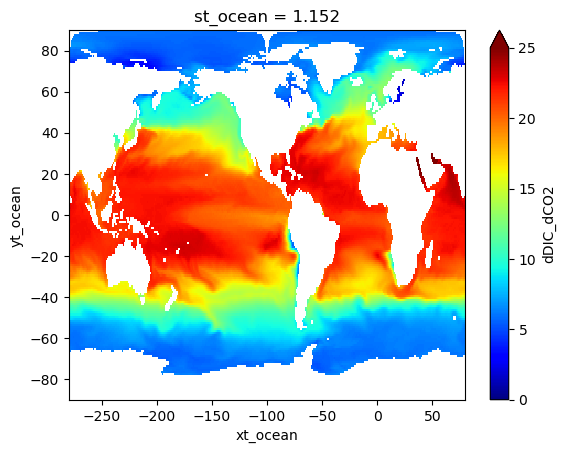

Model Resolution: 0.25 degree


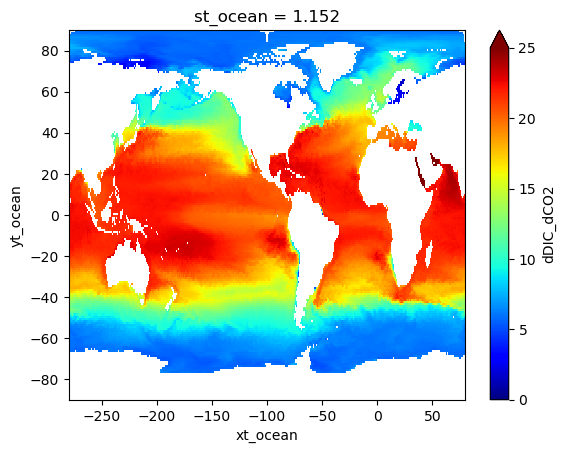

Model Resolution: 0.1 degree


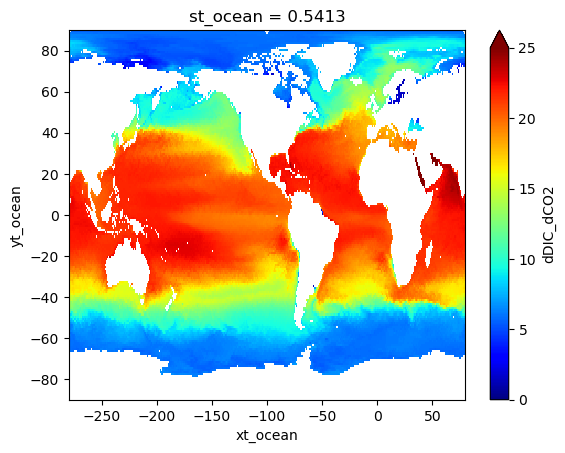

In [12]:
for model_res in [1,0.25,0.1]:
    print(f"Model Resolution: {model_res} degree")
    plt.figure()
    np.max(xr.open_dataset('/g/data/jk72/yx9454/GBC_Revision/'+str(model_res)+'deg_dpco2_ddic_and_dDIC_dCO2.nc').dDIC_dCO2,axis=0).plot(vmin=0,vmax=25,cmap='jet')
    plt.show()


# Calculate ans Save the Parameterized Gas Transfer Velocity (m/d) above the surface layer CO2 deficit residual plume

In [ ]:
def get_res_value(char):
    if char.startswith("1deg_j"):
        return '1'
    elif char.startswith("01deg_"):
        return '0.1'
    elif char.startswith("025deg"):
        return '0.25'
    else:
        return None  # If it does not match any known pattern, return None or another default value


# Input
for i,k_Jan,k_Jul,l in zip([1,0.25,0.1],
                             ['/g/data/jk72/yx9454/PhD_Ch2/access-om2/archive/1deg_jra55_iaf_spin_up_step_5400s_ProbResolve_Site07_16_18_Control_2004/output018/ocean/ocean-3d-dzt-1-monthly-mean-ym_2004_01.nc',
                              '/g/data/gv90/yx9454/access-om2/archive/025deg_jra55_iaf_spin_up_cycle_7_1yr_per_loop/output412/ocean/ocean-3d-dzt-1-monthly-mean-ym_2004_01.nc',
                              '/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_jra55v140_iaf_cycle4/output932/ocean/ocean-3d-dzt-1-monthly-mean-ym_2004_01.nc'],
                             ['/g/data/jk72/yx9454/PhD_Ch2/access-om2/archive/1deg_jra55_iaf_spin_up_step_5400s_ProbResolve_Site07_16_18_Control_2004/output020/ocean/ocean-3d-dzt-1-monthly-mean-ym_2004_07.nc',
                              '/g/data/gv90/yx9454/access-om2/archive/025deg_jra55_iaf_spin_up_cycle_7_1yr_per_loop/output412/ocean/ocean-3d-dzt-1-monthly-mean-ym_2004_01.nc',
                              '/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_jra55v140_iaf_cycle4/output934/ocean/ocean-3d-dzt-1-monthly-mean-ym_2004_07.nc'],
                             ['/g/data/jk72/yx9454/PhD_Ch2/access-om2/archive/1deg_jra55_iaf_spin_up_step_5400s_ProbResolve_Site07_16_18_Control_2004/output018/ocean/ocean-2d-area_t.nc',
                              '/g/data/gv90/yx9454/access-om2/archive/025deg_jra55_iaf_spin_up_cycle_7_1yr_per_loop/output412/ocean/ocean-2d-area_t.nc',
                              '/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_jra55v140_iaf_cycle4/output932/ocean/ocean-2d-area_t.nc'],
                            ):
    if 1 == i:
        #ocean_grid = xr.open_dataset('/g/data/ik11/grids/ocean_grid_'+j+'.nc')
        dzt_Jan_1    =xr.open_dataset(k_Jan).dzt[0]
        dzt_Jul_1    =xr.open_dataset(k_Jul).dzt[0]

    if 0.1 == i:
        #ocean_grid = xr.open_dataset('/g/data/ik11/grids/ocean_grid_'+j+'.nc')
        dzt_Jan_01    = xr.open_dataset(k_Jul).dzt[0]
        dzt_Jul_01    = xr.open_dataset(k_Jul).dzt[0]

    if 0.25 == i:
        dzt_Jan_025    = xr.open_dataset(k_Jan).dzt[0]
        dzt_Jul_025    = xr.open_dataset(k_Jul).dzt[6]

In [42]:
# Initialize the result dictionary
difference_Normalized_3D_Site_files = {'group_1': {}, 'group_2': {}, 'group_3': {}, 'group_4': {}}

# Define the list of experimental directories
All_exp_dirs = [
    '1deg_jra55_iaf_spin_up_step_5400s_Group_1', '025deg_jra55_iaf_cycle_7_Group1', '01deg_jra55_iaf_group1_attempt_2',
    '1deg_jra55_iaf_spin_up_step_5400s_Group_2', '025deg_jra55_iaf_cycle_7_Group2', '01deg_jra55_iaf_group2',
    '1deg_jra55_iaf_spin_up_step_5400s_Group_3', '025deg_jra55_iaf_cycle_7_Group3', '01deg_jra55_iaf_group3',
    '1deg_jra55_iaf_spin_up_step_5400s_Group_4', '025deg_jra55_iaf_cycle_7_Group4', '01deg_jra55_iaf_Group4_3sites_adic_deficit_2004_07_01_07',
]

# go through all the experimental directories
for file_path in All_exp_dirs:
    # Obtain the resolution value from the directory name
    res = get_res_value(file_path[:6])
    # Determine the group
    if 'Group_1' in file_path or 'group1'  in file_path  or 'Group1' in file_path:
        group_key = 'group_1'
    elif 'Group_2' in file_path or 'group2' in file_path  or 'Group2'  in file_path:
        group_key = 'group_2'
    elif 'Group_3' in file_path or 'group3' in file_path  or 'Group3'  in file_path:
        group_key = 'group_3'
    elif 'Group_4' in file_path or 'group4' in file_path  or 'Group4'  in file_path:
        group_key = 'group_4'
    else:
        continue  # If no known groups are matched, skip this file path

    # Obtain the complete path of the current experimental directory 
    #(assuming your experimental directory is in the main_directory under the current working directory)
    full_path = os.path.join(os.getcwd(), main_directory+'/'+file_path)

    # Search for files containing specific patterns
    for file in os.listdir(full_path):
        if "Normalizatied_180x360x50_DIC_deficit_" in file and 'npz' in file:
            # Check if the resolution key value exists in the dictionary. If not, create it
            if res not in difference_Normalized_3D_Site_files[group_key]:
                difference_Normalized_3D_Site_files[group_key][res] = []
            # Add the file path to the corresponding resolution key
            difference_Normalized_3D_Site_files[group_key][res].append(os.path.join(full_path, file))

In [44]:
import pandas as pd
results = []

depth_levels = np.load(difference_Normalized_3D_Site_files['group_1']['0.1'][1])['depth']
site_group_mapping = {'group_1':[4,7,12],'group_2':[5,16,17],'group_3':[6,8,18],'group_4':[3,13,21]}

for group in difference_Normalized_3D_Site_files:
    print(group)
    sites = site_group_mapping[group]
    for res,model_res in zip(['0.1','0.25','1'],[0.1,0.25,1]):
        print(res)
        k_ddic = xr.open_dataset('/g/data/jk72/yx9454/GBC_Revision/Monthly_k_ddic_180x360_'+str(model_res)+'_2004_1_to_2008_12.nc')
        # Month to calculate aligned to 0deg runs
        month_list = []
        for path in sorted(difference_Normalized_3D_Site_files[group]['0.1']):
            match = re.search(r'DIC_deficit_(\d{4})_(\d{2})', path)
            month_list.append(f'{match.group(1)}_{match.group(2)}')
        if res == '0.25':
            month_list = [f"{y}_{int(m)}" for y, m in (s.split('_') for s in month_list)]
        
        dic_list = difference_Normalized_3D_Site_files[group][res]

        for yyyy_mm in month_list:
            print(yyyy_mm)
            target_path = next((f for f in dic_list if f'DIC_deficit_{yyyy_mm}_' in f), None)
            dic_data = np.load(target_path)['data']
            k_ddic_data = k_ddic.sel(time=yyyy_mm.replace('_', '-')).dDIC_dCO2.data[0]
            
            for site in sites:
                mask = np.load('/g/data/jk72/yx9454/PhD_Ch2/Analysis_&_result/Key_fig_surface_PACO2_maps_of_3_resolutions_in_3_and_5_year_with_the_variance/Site_mask_'
                +str(int(site))+'_180_360.npy')
                surface_dic_masked = np.copy(dic_data[0])
                surface_dic_masked[~mask]=np.nan

                # Then calculate weight index for mean MLD calculating
                Total_surface_dic_masked = np.nansum(surface_dic_masked)
                weight_inds = surface_dic_masked/Total_surface_dic_masked
                Mean_k_ddic = np.nansum(k_ddic_data*weight_inds)
                
                results.append({
                    'Resolution': res,
                    'Site': site,
                    'Year_Month': yyyy_mm,
                    'Total_surface_dic_masked': Total_surface_dic_masked,
                    'Mean_k_ddic': Mean_k_ddic,
                })
                
# set up DataFrame
results_df = pd.DataFrame(results)

# Save as a CSV file (read and write repeatedly)
save_path = '/home/581/yx9454/GBC_Revision/Mean_k_ddic_Analysis.csv'
results_df.to_csv(save_path, index=False)      

group_1
0.1
2004_01
2004_02
2004_03
2004_04
2004_05
2004_06
2004_07
2004_08
2004_09
2004_10
2004_11
2004_12
2005_01
2005_02
2005_03
2005_04
2005_05
2005_06
2005_07
2005_08
2005_09
2005_10
2005_11
2005_12
2006_01
2006_02
2006_03
2006_04
2006_05
2006_06
2006_07
2006_08
2006_09
2006_10
2006_11
2006_12
2007_01
2007_02
2007_03
2007_04
2007_05
2007_06
2007_07
2007_08
2007_09
2007_10
2007_11
2007_12
0.25
2004_1
2004_2
2004_3
2004_4
2004_5
2004_6
2004_7
2004_8
2004_9
2004_10
2004_11
2004_12
2005_1
2005_2
2005_3
2005_4
2005_5
2005_6
2005_7
2005_8
2005_9
2005_10
2005_11
2005_12
2006_1
2006_2
2006_3
2006_4
2006_5
2006_6
2006_7
2006_8
2006_9
2006_10
2006_11
2006_12
2007_1
2007_2
2007_3
2007_4
2007_5
2007_6
2007_7
2007_8
2007_9
2007_10
2007_11
2007_12
1
2004_01
2004_02
2004_03
2004_04
2004_05
2004_06
2004_07
2004_08
2004_09
2004_10
2004_11
2004_12
2005_01
2005_02
2005_03
2005_04
2005_05
2005_06
2005_07
2005_08
2005_09
2005_10
2005_11
2005_12
2006_01
2006_02
2006_03
2006_04
2006_05
2006_06
2006_07
2

  weight_inds = surface_dic_masked/Total_surface_dic_masked



2004_02
2004_03
2004_04
2004_05
2004_06
2004_07
2004_08
2004_09
2004_10
2004_11
2004_12
2005_01
2005_02
2005_03
2005_04
2005_05
2005_06
2005_07
2005_08
2005_09
2005_10
2005_11
2005_12
2006_01
2006_02
2006_03
2006_04
2006_05
2006_06
2006_07
2006_08
2006_09
2006_10
2006_11
2006_12
2007_01
2007_02
2007_03
2007_04
2007_05
2007_06
2007_07
2007_08
2007_09
2007_10
2007_11
2007_12
0.25
2004_1


  weight_inds = surface_dic_masked/Total_surface_dic_masked



2004_2
2004_3
2004_4
2004_5
2004_6
2004_7
2004_8
2004_9
2004_10
2004_11
2004_12
2005_1
2005_2
2005_3
2005_4
2005_5
2005_6
2005_7
2005_8
2005_9
2005_10
2005_11
2005_12
2006_1
2006_2
2006_3
2006_4
2006_5
2006_6
2006_7
2006_8
2006_9
2006_10
2006_11
2006_12
2007_1
2007_2
2007_3
2007_4
2007_5
2007_6
2007_7
2007_8
2007_9
2007_10
2007_11
2007_12
1
2004_01


...

2004_02
2004_03
2004_04
2004_05
2004_06
2004_07
2004_08
2004_09
2004_10
2004_11
2004_12
2005_01
2005_02
2005_03
2005_04
2005_05
2005_06
2005_07
2005_08
2005_09
2005_10
2005_11
2005_12
2006_01
2006_02
2006_03
2006_04
2006_05
2006_06
2006_07
2006_08
2006_09
2006_10
2006_11
2006_12
2007_01
2007_02
2007_03
2007_04
2007_05
2007_06
2007_07
2007_08
2007_09
2007_10
2007_11
2007_12


  weight_inds = surface_dic_masked/Total_surface_dic_masked



0.25
2004_1
2004_2
2004_3
2004_4
2004_5
2004_6
2004_7
2004_8
2004_9
2004_10
2004_11
2004_12
2005_1
2005_2
2005_3
2005_4
2005_5
2005_6
2005_7
2005_8
2005_9
2005_10
2005_11
2005_12
2006_1
2006_2
2006_3
2006_4
2006_5
2006_6
2006_7
2006_8
2006_9
2006_10
2006_11
2006_12
2007_1
2007_2
2007_3
2007_4
2007_5
2007_6
2007_7
2007_8
2007_9
2007_10
2007_11
2007_12


  weight_inds = surface_dic_masked/Total_surface_dic_masked



1
2004_01
2004_02
2004_03
2004_04
2004_05
2004_06
2004_07
2004_08
2004_09
2004_10
2004_11
2004_12
2005_01
2005_02
2005_03
2005_04
2005_05
2005_06
2005_07
2005_08
2005_09
2005_10
2005_11
2005_12
2006_01
2006_02
2006_03
2006_04
2006_05
2006_06
2006_07
2006_08
2006_09
2006_10
2006_11
2006_12
2007_01
2007_02
2007_03
2007_04
2007_05
2007_06
2007_07
2007_08
2007_09
2007_10
2007_11
2007_12


## Have a look

In [46]:
df = pd.read_csv('/home/581/yx9454/GBC_Revision/Mean_k_ddic_Analysis.csv')
df

,Resolution,Site,Year_Month,Total_surface_dic_masked,Mean_k_ddic
0,0.1,4,2004_01,7.310505e+12,0.493845
1,0.1,7,2004_01,6.587324e+12,1.650192
2,0.1,12,2004_01,2.904112e+13,0.726078
3,0.1,4,2004_02,1.036310e+13,0.587634
4,0.1,7,2004_02,9.418045e+12,1.333942
...,...,...,...,...,...
1723,1.0,13,2007_11,6.116981e+10,1.460549
1724,1.0,21,2007_11,1.035927e+11,1.927859
1725,1.0,3,2007_12,3.521844e+11,1.007713
1726,1.0,13,2007_12,4.412411e+10,1.690064
